In [1]:
import cv2
import numpy as np
import os
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt

In [2]:
class FaceDetector:
    def __init__(self, face_cascade_path):
        self.face_cascade = cv2.CascadeClassifier(face_cascade_path)
        if self.face_cascade.empty():
            raise IOError("Error loading face cascade xml file")
        
        # All faces will be resized to this for consistency
        self.face_size = (100, 100)

    def find_and_crop_face(self, image_path):
        """Finds the largest face in an image, crops it, and returns it."""
        img = cv2.imread(image_path)
        if img is None:
            print(f"Failed to load {image_path}")
            return None
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        
        # Find all faces
        faces = self.face_cascade.detectMultiScale(gray, 1.1, 5)
        
        if len(faces) == 0:
            return None
            
        # Find the largest face (by area)
        (x, y, w, h) = max(faces, key=lambda f: f[2] * f[3])
        
        # Crop the face from the grayscale image
        face_crop = gray[y:y+h, x:x+w]
        
        # Resize to standard size
        face_resized = cv2.resize(face_crop, self.face_size)
        
        return face_resized

# --- TOOL 2: Eigenface Feature Extractor ---
# (This is the "from-scratch" replacement for a deep learning model)

class EigenfaceModel:
    def __init__(self, num_components=10):
        self.num_components = num_components
        self.mean_face = None
        self.top_eigenvectors = None

    def fit(self, face_list):
        """
        Takes a list of cropped, 100x100 faces and builds the 
        Eigenface model (calculates mean face and principal components).
        """
        print(f"Building Eigenface model from {len(face_list)} faces...")
        
        # 1. Flatten all faces into a data matrix
        # (e.g., 25 faces, 10000 pixels each) -> (25, 10000)
        data = np.array([face.flatten() for face in face_list])
        
        # 2. Calculate the "mean face" (average of all training faces)
        self.mean_face = np.mean(data, axis=0)
        
        # 3. Subtract the mean face from all faces
        data_zero_mean = data - self.mean_face
        
        # 4. Calculate eigenvectors (Eigenfaces) using PCA logic
        # We use SVD for a more efficient PCA calculation
        U, S, Vt = np.linalg.svd(data_zero_mean, full_matrices=False)
        
        # Vt (the eigenvectors) are our "Eigenfaces"
        # These are the "features" it has learned.
        self.top_eigenvectors = Vt[:self.num_components]
        print("✅ Eigenface model built.")

    def encode(self, face_image):
        """
        Takes a *new* cropped face and converts it into a small
        list of numbers (the "encoding") using the Eigenface model.
        """
        if self.mean_face is None:
            raise Exception("Model not fitted yet. Call fit() first.")
            
        # 1. Flatten and subtract the mean face
        flat_face_zero_mean = face_image.flatten() - self.mean_face
        
        # 2. "Project" the face onto the Eigenvectors
        # This is the encoding step.
        encoding = np.dot(self.top_eigenvectors, flat_face_zero_mean)
        
        return encoding

print("Helper classes defined. Ready for Cell 2.")

Helper classes defined. Ready for Cell 2.


In [5]:
FACE_CASCADE_PATH = "haarcascade_frontalface_default.xml"
DATASET_DIR = "dataset"

# (k=5 is a good start)
KNN_NEIGHBORS = 5 

# This is how many "features" the Eigenface model will use.
# It MUST be less than the total number of training images.
EIGENFACE_COMPONENTS = 10

if not os.path.exists(DATASET_DIR):
    print(f"\033[1;91mError: 'dataset' folder not found.\033[0m")
    print("Please create it and add subfolders for each person.")
else:
    detector = FaceDetector(FACE_CASCADE_PATH)
    
    # --- 2. LOAD & CROP ALL FACES ---
    print("Loading training data...")
    all_cropped_faces = []
    all_labels = []
    
    # Loop through subfolders (e.g., "person_1_alice")
    for person_name in os.listdir(DATASET_DIR):
        person_dir = os.path.join(DATASET_DIR, person_name)
        if not os.path.isdir(person_dir):
            continue
            
        # Loop through images in the subfolder
        for image_name in os.listdir(person_dir):
            image_path = os.path.join(person_dir, image_name)
            
            # Find and crop the face
            cropped_face = detector.find_and_crop_face(image_path)
            
            if cropped_face is not None:
                all_cropped_faces.append(cropped_face)
                all_labels.append(person_name)
                print(f"  > Loaded face for: {person_name}")
            else:
                print(f"  > No face found in: {image_path}")

    if not all_cropped_faces:
        print("\033[1;91mError: No faces were loaded. Training failed.\033[0m")
    else:
        # --- 3. TRAIN EIGENFACE MODEL ---
        # (Make sure components is less than total faces)
        num_components = min(EIGENFACE_COMPONENTS, len(all_cropped_faces))
        
        eigen_model = EigenfaceModel(num_components=num_components)
        eigen_model.fit(all_cropped_faces)
        
        # --- 4. CREATE ENCODINGS FOR K-NN ---
        print("Creating encodings for k-NN...")
        known_encodings = [eigen_model.encode(face) for face in all_cropped_faces]
        
        # --- 5. TRAIN K-NN ---
        print("Training k-NN classifier...")
        knn = KNeighborsClassifier(n_neighbors=KNN_NEIGHBORS)
        knn.fit(known_encodings, all_labels)
        
        print(f"\n\033[1;92m✅ SUCCESS: Training complete! Ready to recognize {len(set(all_labels))} people.\033[0m")

Loading training data...
  > Loaded face for: adham
  > Loaded face for: adham
  > Loaded face for: adham
  > Loaded face for: adham
  > Loaded face for: adham
  > Loaded face for: zyad ayman
  > Loaded face for: zyad ayman
  > Loaded face for: zyad ayman
  > Loaded face for: zyad ayman
  > Loaded face for: zyad ayman
Building Eigenface model from 10 faces...
✅ Eigenface model built.
Creating encodings for k-NN...
Training k-NN classifier...

✅ SUCCESS: Training complete! Ready to recognize 2 people.


Closest match distance: 3863.03

---> PREDICTION: UNKNOWN <---


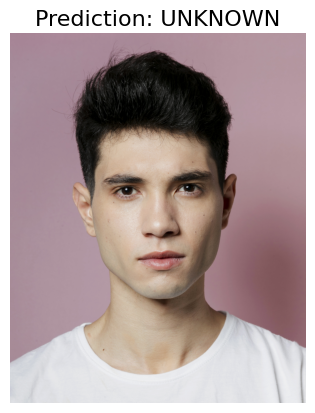

In [10]:
TEST_IMAGE_PATH = "test.jpg"
# ---

# This is the "confidence" threshold. If the closest match is still
# very "far" away, we'll call it "Unknown."
# !!! You will have to experiment with this value!
DISTANCE_THRESHOLD = 3000

if not 'knn' in locals():
    print("\033[1;91mError: Models not trained. Please run Cell 2 first.\033[0m")
elif not os.path.exists(TEST_IMAGE_PATH):
    print(f"\033[1;91mError: Test image not found at '{TEST_IMAGE_PATH}'\033[0m")
else:
    # 1. Load and crop the test face
    test_crop = detector.find_and_crop_face(TEST_IMAGE_PATH)
    
    if test_crop is None:
        print("Result: No face found in the test image.")
    else:
        # 2. Encode the test face
        test_encoding = eigen_model.encode(test_crop)
        
        # 3. Get the "distance" to the closest match(es)
        distances, indices = knn.kneighbors([test_encoding])
        closest_distance = distances[0][0]
        
        print(f"Closest match distance: {closest_distance:.2f}")
        
        # 4. Check against the "Unknown" threshold
        if closest_distance > DISTANCE_THRESHOLD:
            prediction = "UNKNOWN"
        else:
            # 5. Use k-NN to predict the label
            prediction = knn.predict([test_encoding])[0]

        print(f"\n---> PREDICTION: {prediction} <---")

        # 6. Display the result
        test_img_display = cv2.imread(TEST_IMAGE_PATH)
        test_img_rgb = cv2.cvtColor(test_img_display, cv2.COLOR_BGR2RGB)
        
        plt.imshow(test_img_rgb)
        plt.title(f"Prediction: {prediction}", fontsize=16)
        plt.axis('off')
        plt.show()

In [7]:
import os

# 1. This prints exactly where Python is looking
print("I am looking inside this folder:")
print(os.getcwd())

# 2. This checks if the file is actually there
if "test-unkown-person.png" in os.listdir():
    print("\n✅ File FOUND! You are good to go.")
else:
    print("\n❌ File NOT found here.")
    print("Please move your image into the folder printed above.")

I am looking inside this folder:
c:\Users\moamen\Downloads

❌ File NOT found here.
Please move your image into the folder printed above.
